In [2]:
!pip install -q kagglehub


In [3]:
import kagglehub

path = kagglehub.dataset_download("praveengovi/emotions-dataset-for-nlp")

print(path)

100%|██████████| 721k/721k [00:00<00:00, 52.5MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/praveengovi/emotions-dataset-for-nlp/versions/1


In [4]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
            print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/praveengovi/emotions-dataset-for-nlp/versions/1/val.txt
/root/.cache/kagglehub/datasets/praveengovi/emotions-dataset-for-nlp/versions/1/test.txt
/root/.cache/kagglehub/datasets/praveengovi/emotions-dataset-for-nlp/versions/1/train.txt


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix

In [6]:
import os

train = pd.read_csv(
    os.path.join(path, "train.txt"),
    sep=";",
    names=["text", "emotion"]
)

val = pd.read_csv(
  os.path.join(path, "val.txt"),
  sep=";",
  names=["text", "emotion"]
)

test = pd.read_csv(
    os.path.join(path, "test.txt"),
    sep=";",
    names=["text", "emotion"]
)

In [7]:
train.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [8]:
print("Training :", train.shape)
print("Validation :", val.shape)
print("Testing :", test.shape)

Training : (16000, 2)
Validation : (2000, 2)
Testing : (2000, 2)


In [9]:
data = pd.concat([train, val, test], ignore_index=True)

In [10]:
data.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     20000 non-null  object
 1   emotion  20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


In [12]:
data.isnull().sum()

,0
text,0
emotion,0


In [13]:
data.duplicated().sum()

np.int64(1)

In [14]:
data.drop_duplicates(inplace=True)

In [15]:
data.shape

(19999, 2)

In [16]:
data["emotion"].value_counts()

,count
emotion,
joy,6760
sadness,5797
anger,2709
fear,2373
love,1641
surprise,719


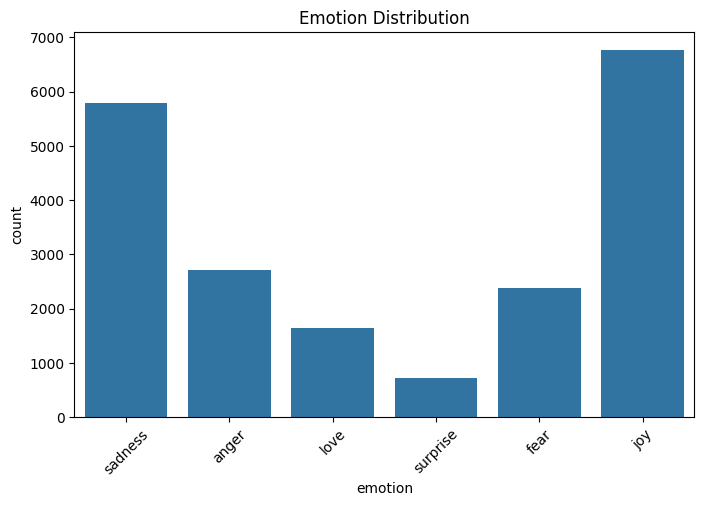

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(data=data, x="emotion")

plt.title("Emotion Distribution")

plt.xticks(rotation=45)

plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data["label"] = encoder.fit_transform(data["emotion"])

In [19]:
data.head()

,text,emotion,label
0,i didnt feel humiliated,sadness,4
1,i can go from feeling so hopeless to so damned...,sadness,4
2,im grabbing a minute to post i feel greedy wrong,anger,0
3,i am ever feeling nostalgic about the fireplac...,love,3
4,i am feeling grouchy,anger,0


In [20]:
emotion_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

print(emotion_mapping)

{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}


In [21]:
X = data["text"]
y = data["label"]

In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X)

In [23]:
sequences = tokenizer.texts_to_sequences(X)

In [24]:
print(X.iloc[0])
print(sequences[0])

i didnt feel humiliated
[2, 139, 3, 626]


In [25]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_pad = pad_sequences(
    sequences,
    maxlen=50,
    padding="post"
)

In [26]:
X_pad.shape

(19999, 50)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(15999, 50)
(4000, 50)
(15999,)
(4000,)


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=50),
        GlobalAveragePooling1D(),
            Dense(64, activation='relu'),
                Dropout(0.3),
                    Dense(32, activation='relu'),
                        Dense(6, activation='softmax')
                        ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(
      optimizer='adam',
          loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
              )

In [32]:
history = model.fit(
      X_train,
          y_train,
              epochs=10,
                  batch_size=32,
                      validation_split=0.2
                      )

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.3328 - loss: 1.5950 - val_accuracy: 0.3344 - val_loss: 1.5593
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.3886 - loss: 1.5065 - val_accuracy: 0.5228 - val_loss: 1.3185
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6596 - loss: 0.9297 - val_accuracy: 0.7231 - val_loss: 0.8228
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7851 - loss: 0.6074 - val_accuracy: 0.7641 - val_loss: 0.6730
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8783 - loss: 0.3763 - val_accuracy: 0.7462 - val_loss: 0.7559
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9166 - loss: 0.2591 - val_accuracy: 0.8294 - val_loss: 0.5519
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9474 - loss: 0.1736 - val_accuracy: 0.8569 - val_loss: 0.4934
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9563 - loss: 0.1380 - val_ac

In [33]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8650 - loss: 0.5286
Test Loss: 0.5286380648612976
Test Accuracy: 0.8650000095367432


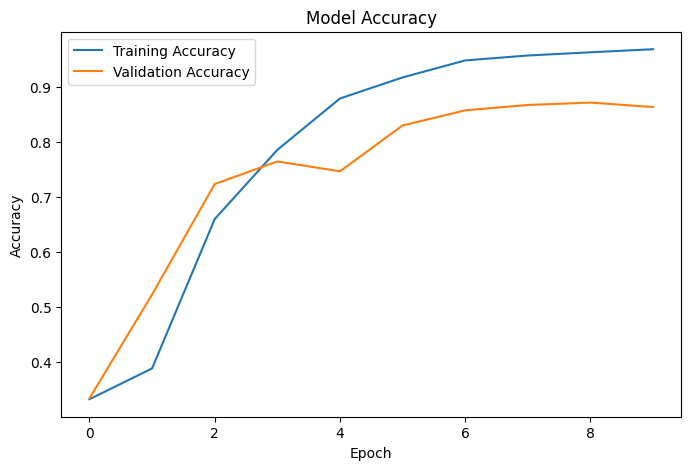

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

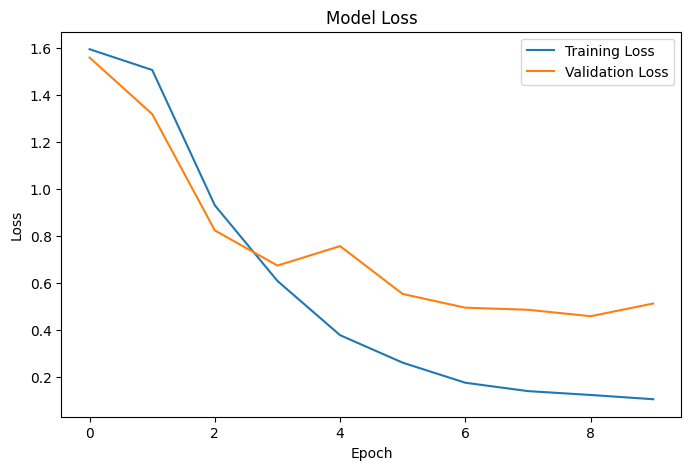

In [35]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [36]:
y_pred = model.predict(X_test)

y_pred = y_pred.argmax(axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83       542
           1       0.85      0.76      0.80       475
           2       0.90      0.90      0.90      1352
           3       0.69      0.86      0.76       328
           4       0.90      0.93      0.92      1159
           5       0.66      0.72      0.68       144

    accuracy                           0.86      4000
   macro avg       0.82      0.82      0.82      4000
weighted avg       0.87      0.86      0.87      4000



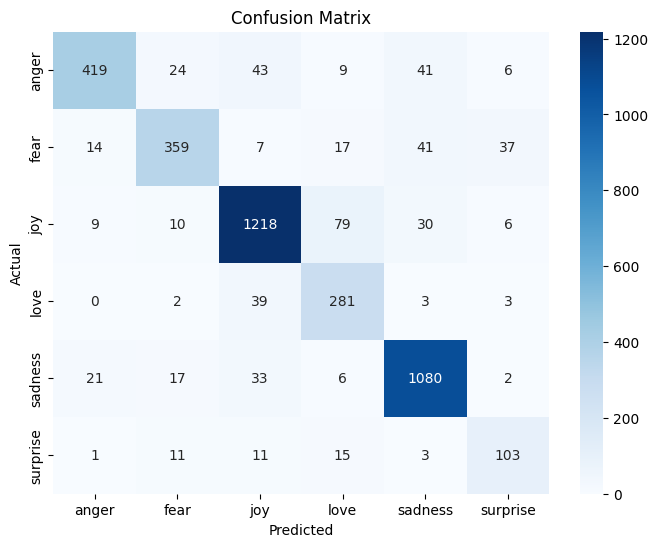

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
                        fmt='d',
                        cmap='Blues',
                        xticklabels=encoder.classes_,
                        yticklabels=encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [39]:
def predict_emotion(text):
      sequence = tokenizer.texts_to_sequences([text])
      padded = pad_sequences(sequence, maxlen=50, padding='post')

      prediction = model.predict(padded, verbose=0)

      predicted_label = prediction.argmax(axis=1)[0]

      emotion = encoder.inverse_transform([predicted_label])[0]

      print("Text:", text)
      print("Predicted Emotion:", emotion)

In [40]:
predict_emotion("I am very happy today")

Text: I am very happy today
Predicted Emotion: joy


In [41]:
predict_emotion("I am feeling very sad")

Text: I am feeling very sad
Predicted Emotion: sadness


In [42]:
predict_emotion("I am really angry")

Text: I am really angry
Predicted Emotion: anger


In [43]:
predict_emotion("I love spending time with my family")

Text: I love spending time with my family
Predicted Emotion: love


In [44]:
predict_emotion("I am scared of the dark")

Text: I am scared of the dark
Predicted Emotion: fear


In [45]:
model.save("emotion_detection_model.h5")

In [49]:
import pickle

with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

with open("label_encoder.pkl","wb") as f:
    pickle.dump(encoder,f)

In [46]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training')
plt.plot(history.history['val_accuracy'],label='Validation')

plt.legend()

plt.title("Accuracy")

plt.savefig("accuracy.png")

plt.show()

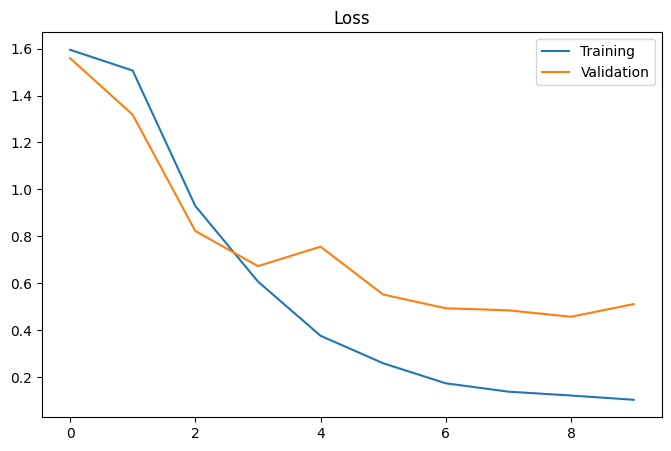

In [47]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training')
plt.plot(history.history['val_loss'],label='Validation')

plt.legend()

plt.title("Loss")

plt.savefig("loss.png")

plt.show()

In [48]:
plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [50]:
from google.colab import files
import os

# List of files to download
project_files = [
    "Emotion_Detection_Using_ANN.ipynb",
    "emotion_detection_model.h5",
    "tokenizer.pkl",
    "label_encoder.pkl",
    "accuracy.png",
    "loss.png",
    "confusion_matrix.png"
]

for file in project_files:
    if os.path.exists(file):
        print(f"Downloading {file}...")
        files.download(file)
    else:
        print(f"❌ {file} not found.")

❌ Emotion_Detection_Using_ANN.ipynb not found.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

❌ accuracy.png not found.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
from google.colab import files
import os

# List of files to download
project_files = [
    "Emotion_Detection_Using_ANN.ipynb",
    "accuracy.png",

]

for file in project_files:
    if os.path.exists(file):
        print(f"Downloading {file}...")
        files.download(file)
    else:
        print(f"❌ {file} not found.")

❌ Emotion_Detection_Using_ANN.ipynb not found.
❌ accuracy.png not found.
